# Bayessian Networks


## Independence
- Two variables are independent if $\forall x,y$ : P(x,y) = P(x)P(Y)
  - *every possible combination of both x and y
  - Also - $\forall x,y$ : P(x|y) = P(x)
  - Says: "Their joint distribution factors into a product of two simpler distributions"
- Shown by writing: $X \perp \perp Y$
- Empirical joint distributions are at best "close" to independendent
  - Most of the time you assume independence for simplicity.
  - *Empirical* - real life values
- Example:
  - P(T)  
  T | P  
  ---|---  
  hot | 0.5  
  cold | 0.5  

  - P(W)  
  W | P  
  ---|---  
  sun | 0.6  
  rain | 0.4  

  - **P₁(T, W)** – dependent  
  T | W | P  
  ---|---|---  
  hot | sun | 0.4  
  hot | rain | 0.1  
  cold | sun | 0.2  
  cold | rain | 0.3  

  - **P₂(T, W)** – independent  
  T | W | P  
  ---|---|---  
  hot | sun | 0.3  
  hot | rain | 0.2  
  cold | sun | 0.3  
  cold | rain | 0.2  

  - P₂(T, W) = P(T) × P(W)  
  All entries in P₂ exactly match the product of the marginals.
  


## Conditional Independence
- P(Toothache, Cavity, Catch)
- If I have a cavity, the probability the doctor catches it doesn't depend on wether I am feeling a toothache
  - So: P(+catch|+toothache, +cavity) = P(+catch|+cavity)
  - Same independence holds if I don't have a cavity:
    - P(+catch|+toothache, -cavity) = P(+catch|-cavity)
- Therefore, the catch is conditionally independent of Toothache given Cavity:
  - P(Catch|Toothache, Cavity) = P(Catch|Cavity)
  - Equivelently (can be derived from above):
    - P(ToothAche|Catch, Cavity) = P(Toothache|Cavity)
    - P(Toothache, Catch | Cavity) = P(Toothache|Cavity) * P(Catch|Cavity)
      - Independence equation
- Unconditional (absolute) independence is very rare.
- *Conditional Independence* is our most basic and robust form of knowledge about uncertain environments.
- X is conditionally independent of Y given Z : $X \perp Y |Z$
  - iff: $\forall x,y,z: P(x,y|z) = P(x|z)P(y|z) OR \forall x,y,z: P(x|z,y) = P(x|z)$

### Conditional Independence and the Chain Rule
- Conditional independence can help to simplify the chain rule.
- This: $P(Traffic, Rain, Umprella) = P(Rain)P(Traffic|Rain)P(Umbrella|Rain, Traffic)$
- Can be simplified to this with the assumption of some conditional independence:
  - $P(Traffic, Rain, Umprella) = P(Rain)P(Traffic|Rain)P(Umbrella|Rain)$

## Bayesain Network Big Picture
- Main Problems with using full joint distriution tables as our probabilistic models:
  - Unless there are only a few vars, the joint is WAY too big to represent explicitly.
  - Hard to learn (estimate) anything empirically about way more than a few variables at a time.
- **Bayes Nets** - a technique for describing complex joint distributions (models) using simple, local distributions (conditional probabilities)
  - More properly called *graphical models*
  - We describe how variables locally interact.
  - Local interactions chain together to give global, indirect interactions
### Graphical Model Notation
- Nodes: Variables
  - Sometimes written with domains.
  - Can be assigned (observed) or unassigned (unobserved)
- Arcs (arrows/edges): interactions
  - Similar to CSP constraints
  - Indicate 'direct influence' between variables
  - Encode conditional independence (more below).
- At this point, assume arrows mean direct causation (thoughts will evolve).

### Different Baye's Net Examples
- Coin flips
  - you can have n number of them
  - There are no interaciton between the variables *absolute independence*
- Traffic
  - Vars:
    - R - It rains
    - T - There is traffic
  - Model 1: Independence:
    - 'R    T'
  - Model 2: Rain Causes Traffic:
    - 'R -> T'
  - Agent using model 2 is better

### Bayes' Net Semantics
- `A` set of nodes, one per variable X
- Directed, acyclic graph
- Conditional distribution exists for each node:
  - A collection of distributions over X (a level above), one for each combination of parents' values
    - $P(X|A_1...A_n)$
  - Describing a noisy "causal" process
  - **Conditional Probability Table (CPT)** - Table that sits inside each node of a Bayes' net and tells you the probability of that node's value, given its parents
- A Bayes Net = Topology (graph) + Local Conditional Probabilities

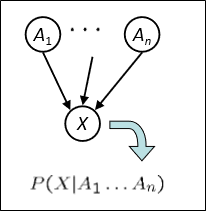

## Probabilities in BNs
- Bayes nets implicitly encode joint distributions as a product of local conditional distributions
- To see what probability a BN gives to a full assignment, multiply all the relevant conditionals together:
  - $P(x_1, x_2, \dots, x_n) = \prod_{i=1}^{n} P(x_i | parents(X_i))$
- Example:

  - Let’s assign:
    - $X_1$ = Cavity  
    - $X_2$ = Toothache  
    - $X_3$ = Catch  

  - We want $P$(+cavity, -toothache, +catch)

  - Now iterate through the product:

  - **i=1** (Cavity): $P(+cavity | parents(Cavity))$  
    → Cavity has no parents, so this is just $P(+cavity)$

  - **i=2** (Toothache): $P(-toothache | parents(Toothache))$  
    → Parent is Cavity, so $P(-toothache | +cavity)$

  - **i=3** (Catch): $P(+catch | parents(Catch))$  
    → Parent is Cavity, so $P(+catch | +cavity)$

  - Final result after multiplying all three terms:

    - $P(+cavity, -toothache, +catch) = P(+cavity) \times P(-toothache | +cavity) \times P(+catch | +cavity)$

- Why are we guaranteed that setting  
  - $P(x_1, x_2, \dots, x_n) = \prod_{i=1}^{n} P(x_i | parents(X_i))$  
  - results in a proper joint distribution?
- Because:
  - Chain rule (valid for all distributions):  $P(x_1, x_2, \dots, x_n) = \prod_{i=1}^{n} P(x_i | x_1 \dots x_{i-1})$

- Assume conditional independences:  
  - $P(x_i | x_1, \dots, x_{i-1}) = P(x_i | parents(X_i))$

- Consequence:  
$P(x_1, x_2, \dots, x_n) = \prod_{i=1}^{n} P(x_i | parents(X_i))$

- Not every BN can represent every joint distribution  
The topology enforces certain conditional independences

- Only distributions whose variables are absolutley independent can be represented by a bayes net with no arcs

### Good BN Example:
- 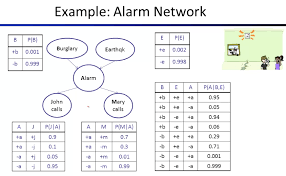
- Important to note that all of the tables on the slide (CPT and the one on the right) must be given

## Causality
- When Bayes' nets reflect the true (IRL) causal patterns:
  - Often simpler (nodes have fewer parents)
  - Often easier to think about and elicit from experts  
- BNs need not actually be causal
  - Sometimes no causal net exists over the domain (especially if variables are missing)
  - E.g. consider the cariables Traffic and Drips
    - You end up with arrows that reflect correlation, not causation
- So, **what do the arrows really mean**?
  - Topology may happen to encode causal structure
  - Topology really **encodes conditional independence**
    - $P(x_1, x_2, \dots, x_n) = \prod_{i=1}^{n} P(x_i | parents(X_i))$

## Size of Bayes' Net
- Joint distribution over N Boolean variables is 2^N
- An N-node net if nodes have up to k parents is $O(N*2^{k+1})$
- Both above situations give you the power to calculate $P(X_1, X_2,... X_n)$
- BNs: Huge space savings
- Also is much easier to elicit local CTP's
  - and faster to answer queries (below)